# OCRP Example Explained Walkthrough

This notebook builds one concrete toy OCRP example from scratch.

It walks through:

1. the local `5x5` LR support window and the local member index `m`
2. orientation clusters and slot packing
3. within-slot attention for one HR token (`top-right`) inside slot `B`
4. pooling into `slot_pooled_ctx[B, top-right]`
5. the router's across-slot choice for that same HR token
6. the final owner selection and output token

The toy region layout, member indices `m`, kept slots, and toy slot metadata (`mass`, `centroid`, `dispersion`) are computed exactly from the `5x5` layout below.

The learned feature values, within-slot scores, pooled vectors, and router logits shown later are illustrative. They are chosen to match the qualitative OCRP behavior we discussed, but they are not copied from a trained checkpoint.


In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from IPython.display import display

plt.rcParams['figure.dpi'] = 120
pd.set_option('display.precision', 4)

def softmax(x):
    x = np.asarray(x, dtype=float)
    z = x - np.max(x)
    e = np.exp(z)
    return e / e.sum()

def m_from_coords(y, x, window_size):
    return int(y * window_size + x)

def coords_from_m(m, window_size):
    y = int(m) // int(window_size)
    x = int(m) % int(window_size)
    return y, x


## General OCRP Picture

Before the toy example, it helps to separate **two different decisions** that OCRP makes:

1. **Within-slot attention**: for one slot `k` and one HR token `t`, which LR members inside that slot matter most?
2. **Across-slot routing**: for one HR token `t`, which slot should own that token?

The overall OCRP pipeline is:

1. build a local LR support bank (`bank_q`, `bank_f`) around each LR window
2. cluster the local LR quaternions into connected orientation components
3. pack the top clusters into deterministic slots and create `slot_mask` / `slot_meta`
4. build one anchor feature per slot
5. for each HR token, attend over the LR members inside each slot to get `slot_pooled_ctx[k, t]`
6. compare the candidate slots for that HR token with the router and choose the owner slot
7. let each slot propose an HR output feature for that token
8. keep only the winning slot's proposal and stitch all HR tokens back into the HR image

One subtle but important detail is that OCRP pools **twice** inside each slot:

1. an anchor-pooling stage builds one coarse feature per slot
2. a token-conditioned pooling stage builds a different `slot_pooled_ctx[k, t]` for different HR tokens

Another useful split is **what is fixed** versus **what is learned**:

- Mostly fixed / deterministic:
  - local member indexing `m`
  - connected-component clustering rule
  - slot packing order once the clusters are ranked
- Learned:
  - the slot anchor weighting
  - the `member_key` and `phase_query` representations
  - the geometric bias terms
  - the router scoring MLPs
  - the patch proposal head

So in plain language, OCRP first says:

- "What local orientation regions exist in this LR neighborhood?"
- "For this HR token, what part of each region is relevant?"
- "Which region should own the token?"
- "What feature should that region write there?"

The rest of the notebook turns that general story into one concrete worked example.


## 1. Local LR Window, Clusters, And The Member Index `m`

OCRP first builds a local `window_size x window_size` support bank around one LR pixel. In this toy example, `window_size = 5`, so there are `25` local LR members and therefore `m = 0 ... 24`.

We will use the same toy local orientation layout as in the discussion:

```text
A A A B B
A A A B B
A A C C B
D D C C B
D D C E E
```

Here `A`-`E` are just toy labels for connected orientation regions inside one local window. They are not class labels or learned slot types.

The connected-component clusterer would assign one raw cluster id to each connected orientation region. Then `ClusterSlotBuilder` keeps the top-ranked clusters and packs them into deterministic slots.


,slot_label,slot_index_k,member_count,member_m_values,mass,centroid_y,centroid_x,dispersion
0,A,0,8,"[0, 1, 2, 5, 6, 7, 10, 11]",0.32,-0.5625,-0.5625,0.3047
1,B,1,6,"[3, 4, 8, 9, 14, 19]",0.24,-0.4167,0.8333,0.3403
2,C,2,5,"[12, 13, 17, 18, 22]",0.20,0.4000,0.2000,0.2000


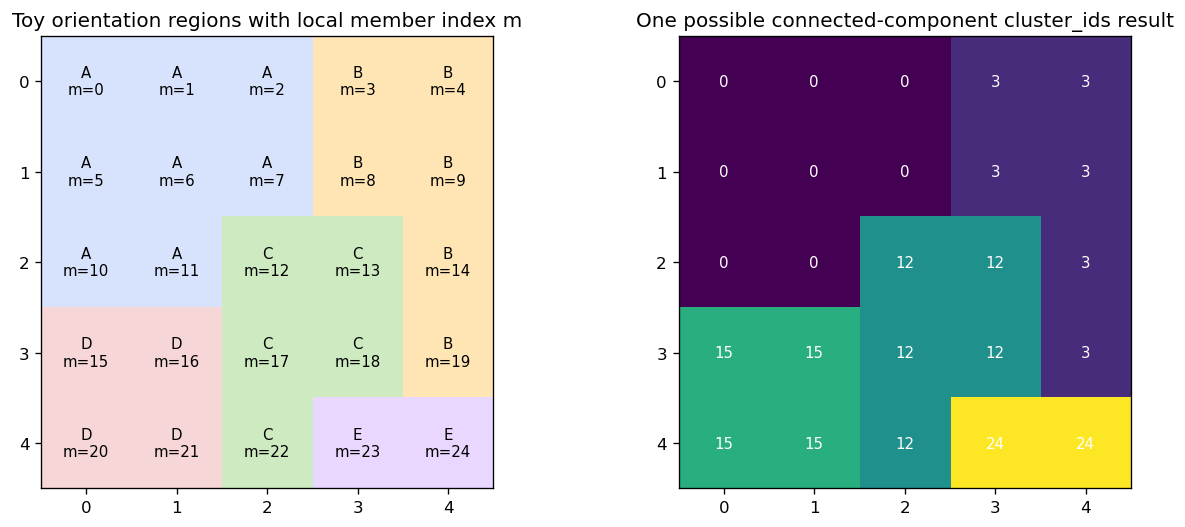

In [20]:
window_size = 5

label_grid = np.array([
    ['A', 'A', 'A', 'B', 'B'],
    ['A', 'A', 'A', 'B', 'B'],
    ['A', 'A', 'C', 'C', 'B'],
    ['D', 'D', 'C', 'C', 'B'],
    ['D', 'D', 'C', 'E', 'E'],
])

cluster_id_grid = np.array([
    [0, 0, 0, 3, 3],
    [0, 0, 0, 3, 3],
    [0, 0, 12, 12, 3],
    [15, 15, 12, 12, 3],
    [15, 15, 12, 24, 24],
])

m_grid = np.arange(window_size * window_size).reshape(window_size, window_size)
den = max(1, window_size // 2)
coords = np.array([
    ((y - den) / den, (x - den) / den)
    for y in range(window_size)
    for x in range(window_size)
], dtype=float)

slot_order = ['A', 'B', 'C']
slot_lookup = {'A': 0, 'B': 1, 'C': 2}
slot_members = {
    label: [int(v) for v in m_grid[label_grid == label]]
    for label in slot_order
}

slot_meta_exact = {}
for label in slot_order:
    members = np.array(slot_members[label], dtype=int)
    member_coords = coords[members]
    centroid = member_coords.mean(axis=0)
    dispersion = ((member_coords - centroid) ** 2).sum(axis=1).mean()
    slot_meta_exact[label] = {
        'mass': len(members) / float(window_size * window_size),
        'centroid_y': centroid[0],
        'centroid_x': centroid[1],
        'dispersion': dispersion,
    }

slot_summary = pd.DataFrame({
    'slot_label': slot_order,
    'slot_index_k': [slot_lookup[label] for label in slot_order],
    'member_count': [int((label_grid == label).sum()) for label in slot_order],
    'member_m_values': [slot_members[label] for label in slot_order],
    'mass': [slot_meta_exact[label]['mass'] for label in slot_order],
    'centroid_y': [slot_meta_exact[label]['centroid_y'] for label in slot_order],
    'centroid_x': [slot_meta_exact[label]['centroid_x'] for label in slot_order],
    'dispersion': [slot_meta_exact[label]['dispersion'] for label in slot_order],
})

display(slot_summary)

label_to_id = {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4}
colors = ListedColormap(['#d7e3fc', '#ffe5b4', '#cdeac0', '#f6d6d6', '#ead7ff'])

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].imshow(np.vectorize(label_to_id.get)(label_grid), cmap=colors, vmin=0, vmax=4)
axes[0].set_title('Toy orientation regions with local member index m')
for y in range(window_size):
    for x in range(window_size):
        axes[0].text(x, y, f"{label_grid[y, x]}\nm={m_grid[y, x]}", ha='center', va='center', fontsize=9)
axes[0].set_xticks(range(window_size))
axes[0].set_yticks(range(window_size))

axes[1].imshow(cluster_id_grid, cmap='viridis')
axes[1].set_title('One possible connected-component cluster_ids result')
for y in range(window_size):
    for x in range(window_size):
        axes[1].text(x, y, str(cluster_id_grid[y, x]), ha='center', va='center', color='white', fontsize=9)
axes[1].set_xticks(range(window_size))
axes[1].set_yticks(range(window_size))

plt.tight_layout()
plt.show()


### From Kept Slots To One Within-Slot Example

In this toy window, the top-3 kept slots are:

- `slot 0 = A`
- `slot 1 = B`
- `slot 2 = C`

Before the token-specific scores below, OCRP first builds one coarse anchor feature per kept slot. The member-level scoring shown next belongs to the second pooling stage, which is token-conditioned.

Now focus on one HR token: the `top-right` token of the `4x4` HR patch emitted by this LR window.

The important point is that the next scoring step is **inside one slot at a time**. It is not yet choosing between `A`, `B`, and `C`. First, OCRP asks which LR members inside slot `B` matter most for the `top-right` HR token.


,alias,actual_m,y,x,description,"score[B, top-right, m]",softmax_weight
0,m1,4,0,4,top-right B,2.1,0.4809
1,m2,3,0,3,upper-middle B,1.5,0.2639
2,m3,9,1,4,middle-right B,0.9,0.1448
3,m4,14,2,4,lower-right B,-0.2,0.0482
4,m5,19,3,4,lower B,-0.5,0.0357
5,m6,8,1,3,boundary-near B,-0.8,0.0265


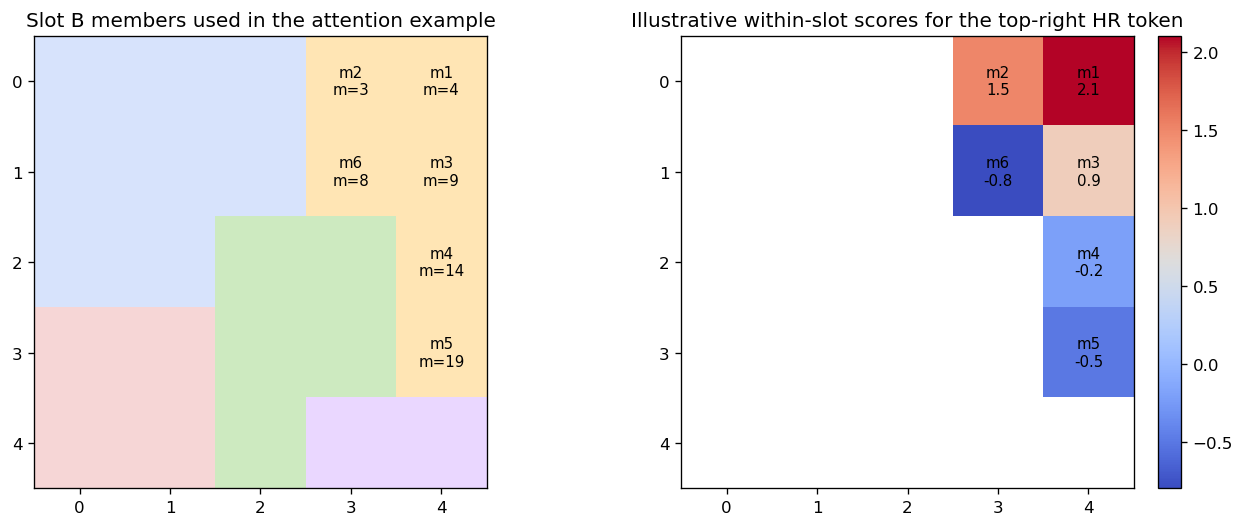

In [21]:
b_members = [
    ('m1', 4,  'top-right B'),
    ('m2', 3,  'upper-middle B'),
    ('m3', 9,  'middle-right B'),
    ('m4', 14, 'lower-right B'),
    ('m5', 19, 'lower B'),
    ('m6', 8,  'boundary-near B'),
]

rows = []
for alias, m_val, desc in b_members:
    y, x = coords_from_m(m_val, window_size)
    rows.append({'alias': alias, 'actual_m': m_val, 'y': y, 'x': x, 'description': desc})

b_member_df = pd.DataFrame(rows)

# Illustrative within-slot scores for the top-right HR token inside slot B.
b_scores = np.array([2.1, 1.5, 0.9, -0.2, -0.5, -0.8])
b_weights = softmax(b_scores)

b_member_df['score[B, top-right, m]'] = b_scores
b_member_df['softmax_weight'] = b_weights
display(b_member_df)

score_grid = np.full((window_size, window_size), np.nan)
for (_, m_val, _), score in zip(b_members, b_scores):
    y, x = coords_from_m(m_val, window_size)
    score_grid[y, x] = score

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].imshow(np.vectorize(label_to_id.get)(label_grid), cmap=colors, vmin=0, vmax=4)
axes[0].set_title('Slot B members used in the attention example')
for alias, m_val, _desc in b_members:
    y, x = coords_from_m(m_val, window_size)
    axes[0].text(x, y, f"{alias}\nm={m_val}", ha='center', va='center', fontsize=9)
axes[0].set_xticks(range(window_size))
axes[0].set_yticks(range(window_size))

masked = np.ma.masked_invalid(score_grid)
im = axes[1].imshow(masked, cmap='coolwarm')
axes[1].set_title('Illustrative within-slot scores for the top-right HR token')
for alias, m_val, _desc in b_members:
    y, x = coords_from_m(m_val, window_size)
    axes[1].text(x, y, f"{alias}\n{score_grid[y, x]:.1f}", ha='center', va='center', fontsize=9)
axes[1].set_xticks(range(window_size))
axes[1].set_yticks(range(window_size))
fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


## 2. What The Within-Slot Scores Mean

For this one slot and one HR token, the pooler computes a score for every valid member of slot `B`; members outside the slot are masked out before the softmax:

```text
score[B, top-right, m]
= bias[B, top-right, m]
+ (1 / sqrt(H)) * <phase_query[B, top-right], member_key[B, m]>
```

Interpretation:

- `phase_query[B, top-right]` says what kind of LR evidence the `top-right` HR token is looking for inside slot `B`
- in the active code path, this query depends on both the slot metadata for `B` and the `top-right` patch position
- `member_key[B, m]` describes LR member `m` as part of slot `B`
- in the active code path, this key is built from invariant anchor-member pair statistics, slot metadata, and the local coordinates of member `m`
- a larger score means member `m` is more relevant for this HR token

So in this toy example, the `top-right` HR token prefers the upper-right `B` members much more than the lower `B` members.


,alias,actual_m,description,weight,f0,f1,f2,weight*f0,weight*f1,weight*f2
0,m1,4,top-right B,0.4809,0.90,0.20,0.10,0.4328,0.0962,0.0481
1,m2,3,upper-middle B,0.2639,0.75,0.25,0.12,0.1979,0.0660,0.0317
2,m3,9,middle-right B,0.1448,0.60,0.30,0.20,0.0869,0.0435,0.0290
3,m4,14,lower-right B,0.0482,0.25,0.55,0.25,0.0121,0.0265,0.0121
4,m5,19,lower B,0.0357,0.10,0.70,0.30,0.0036,0.0250,0.0107
5,m6,8,boundary-near B,0.0265,0.45,0.40,0.15,0.0119,0.0106,0.0040


Illustrative pooled slot feature for slot B and the top-right HR token:
slot_pooled_ctx[B, top-right] = [0.7451 0.2677 0.1355]


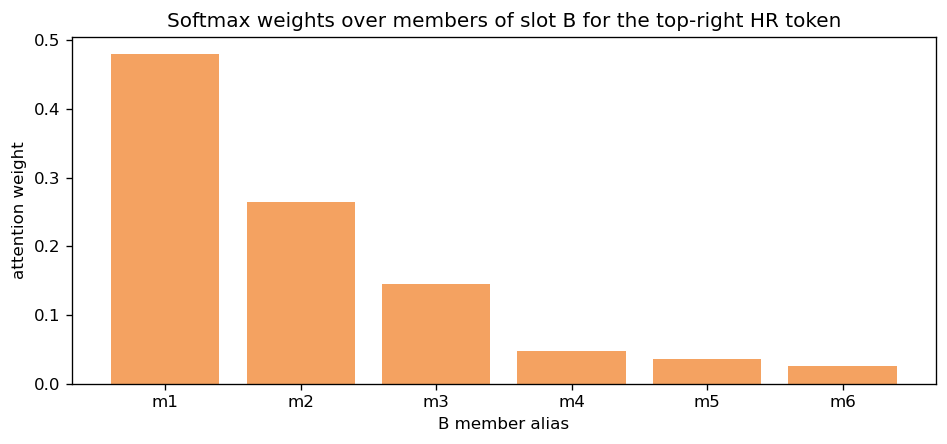

In [22]:
# Toy LR feature vectors for the six B members.
# These stand in for bank_f[m] values restricted to slot B.
bank_f_B = np.array([
    [0.90, 0.20, 0.10],
    [0.75, 0.25, 0.12],
    [0.60, 0.30, 0.20],
    [0.25, 0.55, 0.25],
    [0.10, 0.70, 0.30],
    [0.45, 0.40, 0.15],
])

weighted_contrib = b_weights[:, None] * bank_f_B
pooled_B_top_right = weighted_contrib.sum(axis=0)

pool_df = b_member_df[['alias', 'actual_m', 'description']].copy()
pool_df['weight'] = b_weights
pool_df[['f0', 'f1', 'f2']] = bank_f_B
pool_df[['weight*f0', 'weight*f1', 'weight*f2']] = weighted_contrib
display(pool_df)

print('Illustrative pooled slot feature for slot B and the top-right HR token:')
print('slot_pooled_ctx[B, top-right] =', np.round(pooled_B_top_right, 4))

fig, ax = plt.subplots(figsize=(8, 3.8))
ax.bar(pool_df['alias'], pool_df['weight'], color='#f4a261')
ax.set_title('Softmax weights over members of slot B for the top-right HR token')
ax.set_xlabel('B member alias')
ax.set_ylabel('attention weight')
plt.tight_layout()
plt.show()


This weighted sum is the token-specific pooled feature:

```text
slot_pooled_ctx[B, top-right]
= sum_m alpha[B, top-right, m] * bank_f[m]
```

Now the same pooling logic is run for the other kept slots too, so the router can compare **one candidate feature per slot** for this same HR token:

- `slot_pooled_ctx[A, top-right]`
- `slot_pooled_ctx[B, top-right]`
- `slot_pooled_ctx[C, top-right]`

Only after that does OCRP compare slots against one another.


,slot_label,slot_index_k,illustrative_slot_inv_0,illustrative_slot_inv_1,illustrative_slot_inv_2,actual_mass,actual_centroid_y,actual_centroid_x,actual_dispersion,illustrative_router_logit[top-right]
0,A,0,0.58,0.21,0.10,0.32,-0.5625,-0.5625,0.3047,0.4
1,B,1,0.82,0.36,0.18,0.24,-0.4167,0.8333,0.3403,2.1
2,C,2,0.22,0.41,0.27,0.20,0.4000,0.2000,0.2000,-0.3


Illustrative phase_feat[top-right] = [ 0.75  0.92 -0.35  0.18]
Winning owner slot for the top-right HR token = B
Note: actual_* columns come directly from the toy 5x5 window; the slot_inv values, phase feature, and router logits are illustrative.


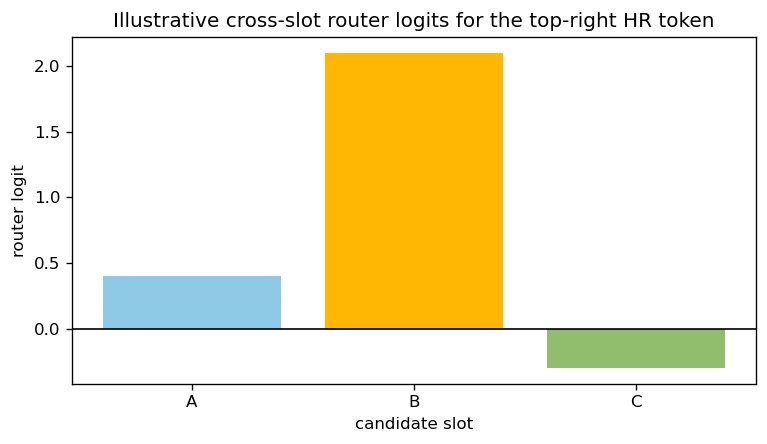

In [23]:
router_table = pd.DataFrame({
    'slot_label': slot_order,
    'slot_index_k': [0, 1, 2],
    'illustrative_slot_inv_0': [0.58, 0.82, 0.22],
    'illustrative_slot_inv_1': [0.21, 0.36, 0.41],
    'illustrative_slot_inv_2': [0.10, 0.18, 0.27],
    'actual_mass': [slot_meta_exact[label]['mass'] for label in slot_order],
    'actual_centroid_y': [slot_meta_exact[label]['centroid_y'] for label in slot_order],
    'actual_centroid_x': [slot_meta_exact[label]['centroid_x'] for label in slot_order],
    'actual_dispersion': [slot_meta_exact[label]['dispersion'] for label in slot_order],
    'illustrative_router_logit[top-right]': [0.4, 2.1, -0.3],
})

phase_feat_top_right = np.array([0.75, 0.92, -0.35, 0.18])
owner_slot = router_table.loc[
    router_table['illustrative_router_logit[top-right]'].idxmax(),
    'slot_label'
]

display(router_table)
print('Illustrative phase_feat[top-right] =', np.round(phase_feat_top_right, 4))
print('Winning owner slot for the top-right HR token =', owner_slot)
print('Note: actual_* columns come directly from the toy 5x5 window; the slot_inv values, phase feature, and router logits are illustrative.')

fig, ax = plt.subplots(figsize=(6.5, 3.8))
ax.bar(router_table['slot_label'], router_table['illustrative_router_logit[top-right]'], color=['#8ecae6', '#ffb703', '#90be6d'])
ax.axhline(0.0, color='black', linewidth=1)
ax.set_title('Illustrative cross-slot router logits for the top-right HR token')
ax.set_xlabel('candidate slot')
ax.set_ylabel('router logit')
plt.tight_layout()
plt.show()


## 3. From Pooled Slot Features To The Owner Slot

In the toy table below, the `actual_*` metadata columns are computed exactly from the `5x5` toy window. The invariant slot features, `phase_feat[top-right]`, and router logits remain illustrative.

For the active OCRP router path, the logic is:

```text
slot_inv[k, t]  = invariant_summary(slot_pooled_ctx[k, t])
slot_desc[k, t] = slot_proj([slot_inv[k, t], slot_meta[k]])
phase_feat[t]   = phase_proj(phase_grid[t])
router_logits[t, k] = base_logit([slot_desc[k, t], phase_feat[t]])
owner_idx[t] = argmax_k router_logits[t, k]
```

In practice, invalid slots are masked before this `argmax` is taken.

In this toy example, slot `B` wins for the `top-right` HR token, so OCRP uses slot `B`'s patch proposal for that token.

That means the full story for one token is:

1. stay inside slot `B` and score its members
2. softmax those scores into attention weights
3. pool the real LR features into `slot_pooled_ctx[B, top-right]`
4. compare slots `A`, `B`, and `C` for ownership of `top-right`
5. choose the highest-logit slot
6. use that slot's proposal as the output feature for the token


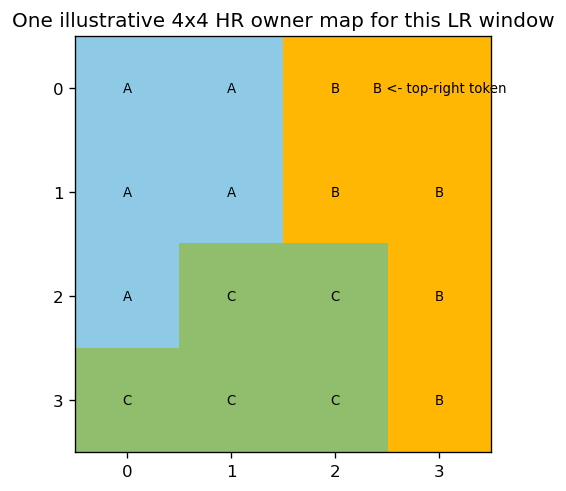

In [24]:
owner_map = np.array([
    [0, 0, 1, 1],
    [0, 0, 1, 1],
    [0, 2, 2, 1],
    [2, 2, 2, 1],
])
slot_name_from_idx = {0: 'A', 1: 'B', 2: 'C'}

fig, ax = plt.subplots(figsize=(4.6, 4.2))
cmap = ListedColormap(['#8ecae6', '#ffb703', '#90be6d'])
ax.imshow(owner_map, cmap=cmap, vmin=0, vmax=2)
ax.set_title('One illustrative 4x4 HR owner map for this LR window')
for y in range(owner_map.shape[0]):
    for x in range(owner_map.shape[1]):
        name = slot_name_from_idx[int(owner_map[y, x])]
        marker = ' <- top-right token' if (y, x) == (0, 3) else ''
        ax.text(x, y, f"{name}{marker}", ha='center', va='center', fontsize=8)
ax.set_xticks(range(owner_map.shape[1]))
ax.set_yticks(range(owner_map.shape[0]))
plt.tight_layout()
plt.show()


## 4. End-To-End Recap

For this toy window:

- `m` is the local LR member index inside the current `5x5` support window
- `slot_mask[k, m]` says whether member `m` belongs to slot `k`
- `score[B, top-right, m]` says how much the `top-right` HR token wants member `m` **inside slot `B`**
- `alpha[B, top-right, m] = softmax(score over B members)` turns those scores into attention weights
- `slot_pooled_ctx[B, top-right]` is the weighted sum of the real LR features in slot `B`
- the router then compares the pooled token-specific features from slots `A`, `B`, and `C`
- the highest-logit slot becomes the owner for that HR token

This is the key split to remember:

- **within-slot attention** decides which LR members matter inside one slot
- **routing** decides which slot owns the HR token across slots
